# Data Preprocessing Project

This notebook demonstrates data loading and exploration using a dataset from Kaggle.

<div class="alert alert-block alert-info">
    1. Import <b>Libraries</b>
</div>

In [4]:
import pandas as pd
import numpy as np
import pickle
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import os

<div class="alert alert-block alert-info">
    2. <b>Data Loading/Reading</b>
</div>

In [5]:
df = pd.read_csv("data.csv")

<div class="alert alert-block alert-info">
    3. <b>Data Exploration</b>
</div>

In [157]:
df.head(5)

,User_ID,Age_Years,Gender,Body_Mass_KG,Height_CM,Steps,Workout_Minutes,Exercise_Type,Avg_Heart_Rate,Intensity_Score,Calories_Burned,Notes,Calories
0,1,56.7,Female,85.3,194.1,10537,27,HIIT,107,9,2246.6,NaN,2251.0
1,2,46.6,Male,46.8,193.5,3422,75,Cycling,118,5,1903.5,High intensity,1903.0
2,3,32.5,Female,81.1,168.3,15604,36,HIIT,177,8,2657.4,High intensity,2656.0
3,4,60.5,Female,89.7,167.9,5721,15,Running,179,4,1912.2,Morning session,1914.0
4,5,25.2,Female,92.8,150.3,10203,112,HIIT,63,1,2336.8,Evening workout,2333.0


In [158]:
df.tail(5)

,User_ID,Age_Years,Gender,Body_Mass_KG,Height_CM,Steps,Workout_Minutes,Exercise_Type,Avg_Heart_Rate,Intensity_Score,Calories_Burned,Notes,Calories
4995,4996,33.4,Male,81.6,159.7,4868,101,Cycling,125,6,2340.5,Morning session,2341.0
4996,4997,22.2,Female,116.8,180.6,9506,11,Swimming,89,10,2141.2,Evening workout,2141.0
4997,4998,38.3,Female,71.2,193.4,6950,66,Running,163,5,2281.7,High intensity,2281.0
4998,4999,27.7,Male,91.4,174.6,9914,14,HIIT,62,9,1955.1,Evening workout,1954.0
4999,5000,36.1,Male,50.0,169.6,15141,80,Running,82,6,2459.5,Evening workout,2456.0


In [278]:
df.shape

(5000, 13)

In [160]:
df.columns

Index(['User_ID', 'Age_Years', 'Gender', 'Body_Mass_KG', 'Height_CM', 'Steps',
       'Workout_Minutes', 'Exercise_Type', 'Avg_Heart_Rate', 'Intensity_Score',
       'Calories_Burned', 'Notes', 'Calories'],
      dtype='object')

In [161]:
df = df.rename(columns={
    "Age_Years": "Age",
    "Body_Mass_KG": "Body_Mass",
    "Height_CM": "Height"
})

In [162]:
df.count()

User_ID            5000
Age                4970
Gender             4950
Body_Mass          4975
Height             4980
Steps              5000
Workout_Minutes    5000
Exercise_Type      4960
Avg_Heart_Rate     5000
Intensity_Score    5000
Calories_Burned    5000
Notes              3521
Calories           4985
dtype: int64

In [163]:
df.describe()

,User_ID,Age,Body_Mass,Height,Steps,Workout_Minutes,Avg_Heart_Rate,Intensity_Score,Calories_Burned,Calories
count,5000.000000,4970.000000,4975.000000,4980.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,4985.000000
mean,2500.500000,41.623924,82.565588,172.215201,10789.503600,64.155600,120.447600,5.607200,2386.357340,2386.312337
std,1443.520003,13.540907,21.597098,12.981243,5499.044128,32.048838,34.776497,2.867499,433.337144,433.162276
min,1.000000,18.000000,45.100000,150.000000,1003.000000,10.000000,60.000000,1.000000,1087.500000,1092.000000
25%,1250.750000,29.900000,63.650000,161.200000,6031.250000,37.000000,90.000000,3.000000,2080.375000,2080.000000
50%,2500.500000,41.800000,82.400000,172.000000,10999.500000,64.000000,121.000000,6.000000,2388.700000,2389.000000
75%,3750.250000,53.200000,101.300000,183.300000,15625.000000,92.000000,151.000000,8.000000,2694.025000,2693.000000
max,5000.000000,64.900000,119.900000,194.900000,19993.000000,119.000000,179.000000,10.000000,3713.600000,3709.000000


In [164]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 13 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   User_ID          5000 non-null   int64  
 1   Age              4970 non-null   float64
 2   Gender           4950 non-null   object 
 3   Body_Mass        4975 non-null   float64
 4   Height           4980 non-null   float64
 5   Steps            5000 non-null   int64  
 6   Workout_Minutes  5000 non-null   int64  
 7   Exercise_Type    4960 non-null   object 
 8   Avg_Heart_Rate   5000 non-null   int64  
 9   Intensity_Score  5000 non-null   int64  
 10  Calories_Burned  5000 non-null   float64
 11  Notes            3521 non-null   object 
 12  Calories         4985 non-null   float64
dtypes: float64(5), int64(5), object(3)
memory usage: 507.9+ KB


In [165]:
print(f"Number of Rows: {df.shape[0]} and Number of Columns: {df.shape[1]}")

Number of Rows: 5000 and Number of Columns: 13


In [166]:
df['Gender'].unique()

array(['Female', 'Male', nan], dtype=object)

In [167]:
df.nunique()

User_ID            5000
Age                 469
Gender                2
Body_Mass           748
Height              450
Steps              4406
Workout_Minutes     110
Exercise_Type         6
Avg_Heart_Rate      120
Intensity_Score      10
Calories_Burned    4282
Notes                 5
Calories           1685
dtype: int64

In [168]:
df.isnull().sum()

User_ID               0
Age                  30
Gender               50
Body_Mass            25
Height               20
Steps                 0
Workout_Minutes       0
Exercise_Type        40
Avg_Heart_Rate        0
Intensity_Score       0
Calories_Burned       0
Notes              1479
Calories             15
dtype: int64

<div class="alert alert-block alert-info">
    4. <b>Data Pre-Processing</b>
</div>

<div class="alert alert-block alert-warning">
    4.1. <b>Manage Null Values</b>
</div>

In [169]:
df.drop(['Notes', 'Calories_Burned'], axis=1, inplace=True)

In [170]:
df['Calories'].mean()

np.float64(2386.312337011033)

In [199]:
df['Calories'].median()

2389.0

In [171]:
df['Calories'].mode().iloc[0]

np.float64(2266.0)

In [ ]:
def fillnaObjectMode(cols):
    for col in cols:
        if col in df.columns:
            df[col] = df[col].fillna(df[col].mode()[0] if not df[col].mode().empty else 'Unknown')
object_cols = [
    'Gender', 'Exercise_Type'
]
fillnaObjectMode(object_cols)

In [235]:
def fillnaNumericMedian(cols):
    for col in cols:
        if col in df.columns:
            df[col] = df[col].fillna(df[col].median() if not np.isnan(df[col].median()) else 0)
numeric_cols = ['Age', 'Body_Mass', 'Height','Calories']
fillnaNumericMedian(numeric_cols)
print("\nNull Values After Filling:")
print(df.isnull().sum())


Null Values After Filling:
User_ID            0
Age                0
Gender             0
Body_Mass          0
Height             0
Steps              0
Workout_Minutes    0
Exercise_Type      0
Avg_Heart_Rate     0
Intensity_Score    0
Calories           0
dtype: int64


<div class="alert alert-block alert-warning">
    4.2. <b>Manage Data Types</b>
</div>

In [240]:
def CHANGEFLOATTOINT(cols):
    for i in cols:
        df[i] = df[i].astype('int32')

int_columns = ['Height','Age','Body_Mass','Calories']
CHANGEFLOATTOINT(int_columns)

In [243]:
def CHANGEObjectTOINT(cols):
    for i in cols:
        data = pd.DataFrame({i: df[i].unique()})
        data_LE = LabelEncoder()
        data_LE.fit(np.ravel(data))
        df[i] = data_LE.transform(df[i])

categorical_columns = ['Gender', 'Exercise_Type']
CHANGEObjectTOINT(categorical_columns)

In [207]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype
---  ------           --------------  -----
 0   User_ID          5000 non-null   int32
 1   Age              5000 non-null   int32
 2   Gender           5000 non-null   int64
 3   Body_Mass        5000 non-null   int32
 4   Height           5000 non-null   int32
 5   Steps            5000 non-null   int32
 6   Workout_Minutes  5000 non-null   int32
 7   Exercise_Type    5000 non-null   int64
 8   Avg_Heart_Rate   5000 non-null   int32
 9   Intensity_Score  5000 non-null   int32
 10  Calories         5000 non-null   int32
dtypes: int32(9), int64(2)
memory usage: 254.0 KB


In [244]:
df.head(2)

,User_ID,Age,Gender,Body_Mass,Height,Steps,Workout_Minutes,Exercise_Type,Avg_Heart_Rate,Intensity_Score,Calories
0,1,56,0,85,194,10537,27,1,107,9,2251
1,2,46,1,46,193,3422,75,0,118,5,1903


In [209]:
df.to_csv('processed_data.csv', index=False, header=True)

In [245]:
df = pd.read_csv('processed_data.csv')

In [246]:
print(os.getcwd())  
print(os.listdir())

s:\SEMESTER 3\AI(Lab)\Project
['.env', '.git', '.gitignore', 'app.py', 'data.csv', 'distribution_analysis.png', 'model_rf.pkl', 'prediction_history.json', 'preprocessing.ipynb', 'processed_data.csv', 'README.md', 'requirements.txt', 'templates']


<div class="alert alert-block alert-info">
    5. <b>Train - Test Splitting</b>
</div>

In [23]:
df = pd.read_csv('processed_data.csv')

In [248]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype
---  ------           --------------  -----
 0   User_ID          5000 non-null   int64
 1   Age              5000 non-null   int64
 2   Gender           5000 non-null   int64
 3   Body_Mass        5000 non-null   int64
 4   Height           5000 non-null   int64
 5   Steps            5000 non-null   int64
 6   Workout_Minutes  5000 non-null   int64
 7   Exercise_Type    5000 non-null   int64
 8   Avg_Heart_Rate   5000 non-null   int64
 9   Intensity_Score  5000 non-null   int64
 10  Calories         5000 non-null   int64
dtypes: int64(11)
memory usage: 429.8 KB


In [249]:
df.columns

Index(['User_ID', 'Age', 'Gender', 'Body_Mass', 'Height', 'Steps',
       'Workout_Minutes', 'Exercise_Type', 'Avg_Heart_Rate', 'Intensity_Score',
       'Calories'],
      dtype='object')

In [24]:
X = df.drop('Calories', axis=1)   
Y = df['Calories']

In [25]:
train_x, test_X, train_y, test_y = train_test_split(X, Y, test_size=0.2, shuffle=True)

In [17]:
print(train_x.shape, train_y.shape)
print(test_X.shape, test_y.shape)

(4000, 12) (4000,)
(1000, 12) (1000,)


<div class="alert alert-block alert-info">
    6. <b>Applying Classifier / Model Training</b>
</div>

In [26]:
model_rf = LinearRegression()

In [27]:
model_rf.fit(train_x, train_y)
print(model_rf)

LinearRegression()


In [28]:
predictions = model_rf.predict(test_X)
model_pred_rf = predictions
print(predictions)

[2088.67682848 3477.33179202 2686.82071111 2788.07610256 2424.71992346
 1944.20414951 2138.17842559 2019.52322955 2207.47462346 2479.23904901
 2209.65353614 2787.63870532 2323.30268463 2296.62856799 2327.80324376
 2292.65302022 3265.32678995 2975.28194401 3051.11036517 2271.83985742
 2176.77778028 2370.38256081 3085.26389296 2131.93114801 1792.08154199
 2541.52444495 1685.29868817 3054.3525005  1811.42116823 2178.8865727
 1849.62788147 1879.0776209  2278.78984718 2642.49359276 1617.09468295
 2367.12035597 2514.08609933 1494.75380334 2213.29705177 2364.53806361
 1959.70461937 2375.46008156 2470.71274313 2419.56188341 2664.90655824
 1973.65702295 2077.10360096 2180.60497033 2393.8168433  2052.57485826
 2860.00458913 2419.04018184 2349.91070656 3035.08972045 2305.95998806
 2809.77261621 2776.48752481 2356.37676588 2075.36535322 2730.06865873
 1647.36263242 2419.00041758 2382.60603845 2398.98290715 1922.01800217
 2923.88332192 1698.06340283 1946.71040762 2130.82174276 1757.85380842
 1490.4

In [29]:
r2 = r2_score(test_y, predictions)
mae = mean_absolute_error(test_y, predictions)
mse = mean_squared_error(test_y, predictions)
rmse = np.sqrt(mse)

print(f"R² Score: {r2:.3f}")
print(f"MAE: {mae:.2f}")
print(f"MSE: {mse:.2f}")
print(f"RMSE: {rmse:.2f}")

R² Score: 0.988
MAE: 19.24
MSE: 2249.75
RMSE: 47.43


In [257]:
model_acc_rf = r2
print(round(model_acc_rf * 100, 4), "%")

99.2627 %


<div class="alert alert-block alert-success">
    6.1. <b>Model Evaluation Graph</b>
</div>

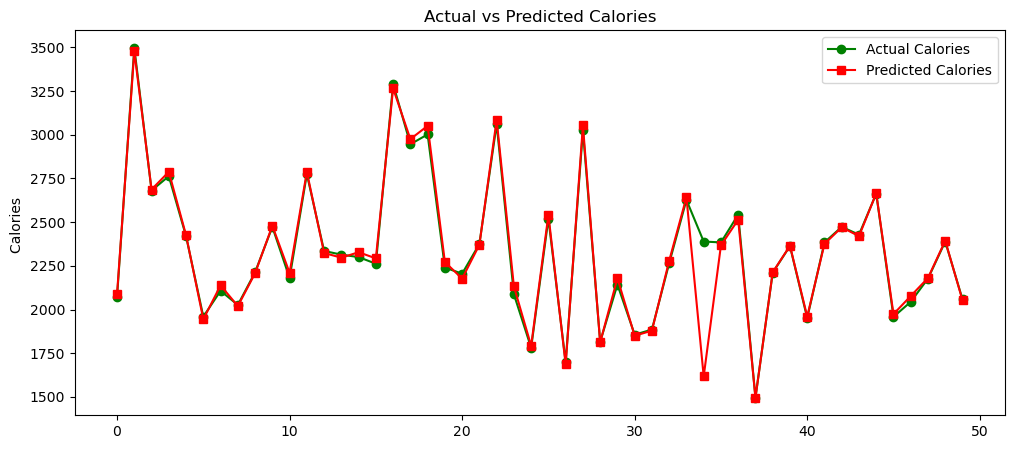

In [30]:
plt.figure(figsize=(12, 5))
plt.plot(test_y.values[:50], color='green', marker='o', label='Actual Calories')
plt.plot(predictions[:50], color='red', marker='s', label='Predicted Calories')
plt.ylabel('Calories ')
plt.title('Actual vs Predicted Calories')
plt.legend()
plt.show()

In [266]:
pickle.dump(model_rf, open('model_rf.pkl', 'wb'))

In [267]:
model_rf = pickle.load(open('model_rf.pkl', 'rb'))